In [ ]:
# %pip install pandas scikit-learn matplotlib seaborn jupyter numpy scipy

In [2]:
import pandas as pd

In [3]:
# Load dataset and remove missing values from relevant columns
df = pd.read_csv("./data/pricerunner_aggregate.csv")   
df = df.dropna()

df.head()

,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label
0,1,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones


In [4]:
# Dataset Columns
df.columns

Index(['Product ID', 'Product Title', ' Merchant ID', ' Cluster ID',
       ' Cluster Label', ' Category ID', ' Category Label'],
      dtype='object')

In [5]:
# Clean text data
import re

def clean_text(t):
    t = t.lower()
    t = re.sub(r'http\S+', '', t)
    t = re.sub(r'[^a-zA-Z0-9\s]', '', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t


In [6]:
# Apply preprocessing
texts = df["Product Title"].apply(clean_text)
texts.head()

0                      apple iphone 8 plus 64gb silver
1                  apple iphone 8 plus 64 gb spacegrau
2    apple mq8n2ba iphone 8 plus 64gb 55 12mp sim f...
3                  apple iphone 8 plus 64gb space grey
4    apple iphone 8 plus gold 55 64gb 4g unlocked s...
Name: Product Title, dtype: object

In [7]:
# Vectorize the texts
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.9,
    min_df=5,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(texts)

In [8]:
# Choose the number of clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score


inertia = []

K = range(2, 21)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    print(k, score)
    inertia.append(km.inertia_)


2 0.009451354584671843
3 0.013293653625338228
4 0.018909312979411112
5 0.01586396606371886
6 0.016221908764576187
7 0.018626428547058833
8 0.027558171267885245
9 0.029673185610037296
10 0.0262282718621867
11 0.029947601537660518
12 0.030021620977120113
13 0.032511551573427014
14 0.03431362743947646
15 0.034731717622043544
16 0.038614912597849035
17 0.03965097161727916
18 0.038475494559987666
19 0.03928064033798855
20 0.041066790270702556


In [11]:
from sklearn.metrics import silhouette_score
# Fit K-Means
k = 10

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

sil = silhouette_score(X, clusters)
print("Silhouette score:", sil)

df["text_cluster"] = clusters
df.head() 

Silhouette score: 0.03561144393035224


,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label,text_cluster
0,1,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,0
1,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,0
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,0
3,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,0
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones,0


In [ ]:
# Top Words per Cluster
import numpy as np

terms = vectorizer.get_feature_names_out()

for i in range(k):
    center = kmeans.cluster_centers_[i]
    top = np.argsort(center)[-12:]

    print(f"\nCluster {i}:")
    print(", ".join(terms[j] for j in top))



Cluster 0:
free, dual, digital camera, body, canon, sim free, digital, smartphone, sony, sim, black, camera

Cluster 1:
cat s41, cat s60, casing, frost, serie, edelstahl, refrigerator, schwarz, freezer, gefrierschrank, dishwasher, bosch

Cluster 2:
size, 60cm, freestanding dishwasher, slimline, dishwasher white, hotpoint, fully integrated, fully, place, integrated, integrated dishwasher, dishwasher

Cluster 3:
freestanding fridge, freestanding, smeg, free fridge, white, freezer white, free, frost free, frost, fridge, freezer, fridge freezer

Cluster 4:
5kg, hotpoint, 7kg, freestanding washer, wash, dry, integrated washer, white, dryer white, washer dryer, dryer, washer

Cluster 5:
inch, smart tv, lg, ultra hd, ultra, hdr, led tv, 4k, led, smart, hd, tv

Cluster 6:
geschirrsp, larder, ler, aeg, freezer, built, white, bosch, liebherr, fridge, siemens, microwave

Cluster 7:
freestanding washing, 1400, spin washing, 9kg, 8kg, 1400rpm, spin, white, machine white, washing, washing machine, 

In [ ]:
# pd.crosstab(df["text_cluster"], df["Category Label"])

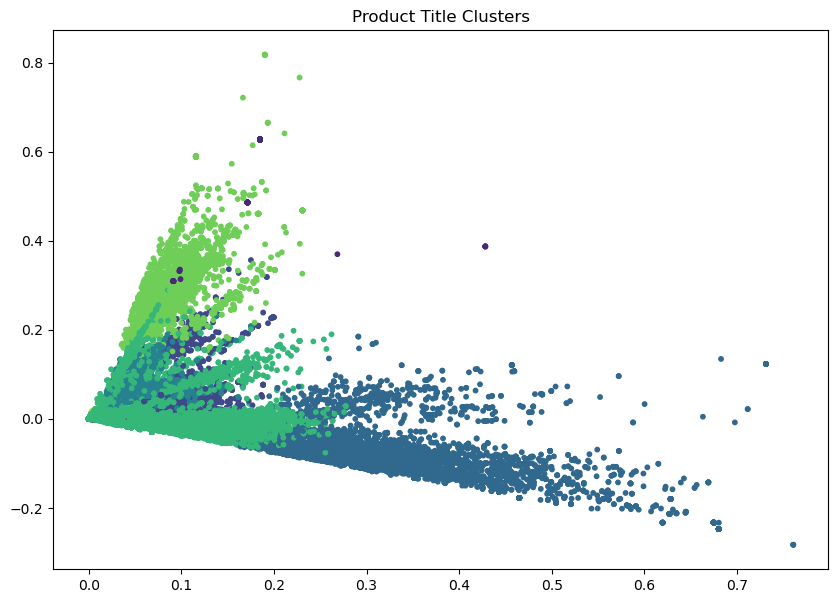

In [ ]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X)

df["x"] = X_2d[:,0]
df["y"] = X_2d[:,1]

plt.figure(figsize=(10,7))
plt.scatter(df["x"], df["y"], c=df["text_cluster"], s=10)
plt.title("Product Title Clusters")
plt.show()
